# CCO03: Pericytes, Endothelial Cells, and Cardiomyocytes

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import os
import glob
import scipy

In [2]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03

In [3]:
DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/240603'
OUT_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO03'

In [4]:
marker_genes = ['PECAM1', 'CDH5', 
                'PDGFRB', 'ACTA2', 
                'TNNI1', 'TNNC1', 'TNNT2', 
                'NPPA', 'NPPB', 'MYH7', 'MYL2']
# Endothelial cell
# Pericyte and smooth muscle cells
# Cardiomyocytes
# Cardiomyocyte maturation

## 1. make sure all adata has all marker genes

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata

In [6]:
%%capture

for d1 in glob.glob(f"{DATA_DIR}/*"):
    if not os.path.isdir(d1):
        continue
    else:
        sample_name = d1.split('/')[-1]
    
    # load h5 file
    adata = sc.read_10x_h5(f'{d1}/filtered_feature_bc_matrix.h5')
    adata.var_names_make_unique()
    
    # qc
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
    
    # processing 
    sc.pp.filter_cells(adata, min_genes=200)
    # sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=5000)
    adata.raw = adata
    
    # adata = adata[:, adata.var['highly_variable']]
    # sc.pp.scale(adata, max_value=10)
    
    # prepare umap
    # sc.tl.pca(adata, svd_solver='arpack')
    # sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    # sc.tl.leiden(adata)
    # sc.tl.umap(adata)
    
    # write to h5ad
    adata.write(f'{OUT_DIR}/adata/{sample_name}.h5ad')

In [7]:
for f in glob.glob(f'{OUT_DIR}/adata/*'):
    adata = sc.read_h5ad(f)
    print(f'working on {f}')
    for gene in marker_genes:
        if gene not in adata.var_names:
            print(f'{gene} not in adata')

working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__BHO-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__BVO-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__CM3B-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__CM3O-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__HO-JW-052224.h5ad


## 2. Co-Embed Everything on One UMAP Axis

In [8]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/coembed

In [9]:
adata_bho = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__BHO-JW-052224.h5ad')
adata_bvo = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__BVO-JW-052224.h5ad')
adata_cm3b = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__CM3B-JW-052224.h5ad')
adata_cm3o = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__CM3O-JW-052224.h5ad')
adata_ho = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__HO-JW-052224.h5ad')

In [10]:
adata_all = adata_bho.concatenate(adata_bvo, adata_cm3b, adata_cm3o, adata_ho, batch_key='batch')

batch_mapping = {
    '0': 'BHO',
    '1': 'BVO',
    '2': 'CM3B',
    '3': 'CM3O',
    '4': 'HO'
}

adata_all.obs['batch'] = adata_all.obs['batch'].map(batch_mapping)

sc.pp.scale(adata_all, max_value=10)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [11]:
# proporgate knn graph

n_neighbors = 1000
sc.tl.pca(adata_all, svd_solver='arpack', n_comps=100, random_state=42)
sc.pp.neighbors(adata_all, n_pcs=100, n_neighbors=n_neighbors, random_state=42)
sc.tl.umap(adata_all)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
adata_all.write(f'{OUT_DIR}/coembed/SC160__ALL-JW-052224.h5ad')

In [13]:
for exp in ['BHO','BVO','CM3B','CM3O','HO']:
    adata_all[adata_all.obs['batch'] == exp, :].write(f'{OUT_DIR}/coembed/SC160__{exp}-JW-052224.h5ad')

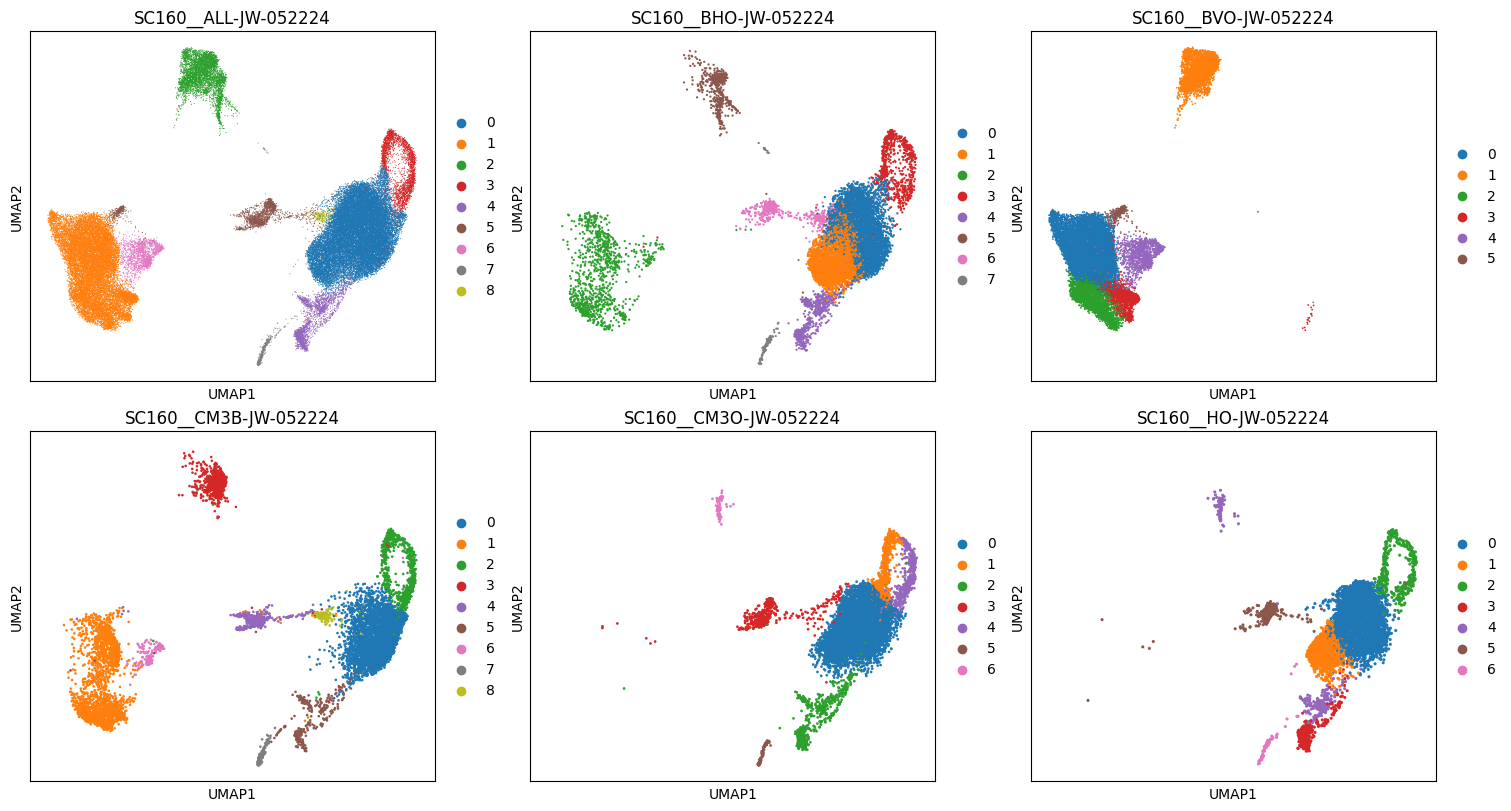

In [181]:
%%capture --no-display

fig, axs = plt.subplots(2, 3, figsize=(15,8), layout="constrained")
axs = axs.flatten()

for i, f in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad')):
    sample_name = f.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f)
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.leiden(adata, resolution=0.25)
    adata.write(f'{OUT_DIR}/coembed/{sample_name}.h5ad.clustered')
    
    axs[i] = sc.pl.umap(adata, color='leiden', ax=axs[i], title=sample_name, show=False)
    if i == 0:
        xlim_ref = axs[i].get_xlim()
        ylim_ref = axs[i].get_ylim()
    else:
        axs[i].set_xlim(xlim_ref)
        axs[i].set_ylim(ylim_ref)
    
plt.savefig(f'{OUT_DIR}/coembed/umaps.png')
plt.show()

## 3. Visualize marker positive cells

In [6]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/gene_marker_umap

In [7]:
%%capture --no-display

for gene in marker_genes:

    try:
        
        fig, axs = plt.subplots(2, 3, figsize=(15,6), layout="constrained")
        axs = axs.flatten()

        for i, f in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad.clustered')):
            sample_name = f.split('/')[-1].strip('.h5ad.clustered')
            adata = sc.read_h5ad(f)
            axs[i] = sc.pl.umap(adata, color=gene, ax=axs[i], title=sample_name, show=False)
            if i == 0:
                xlim_ref = axs[i].get_xlim()
                ylim_ref = axs[i].get_ylim()
            else:
                axs[i].set_xlim(xlim_ref)
                axs[i].set_ylim(ylim_ref)

        plt.savefig(f'{OUT_DIR}/gene_marker_umap/{gene}.png')
    
    except:
        continue
        
    finally:
        plt.close()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

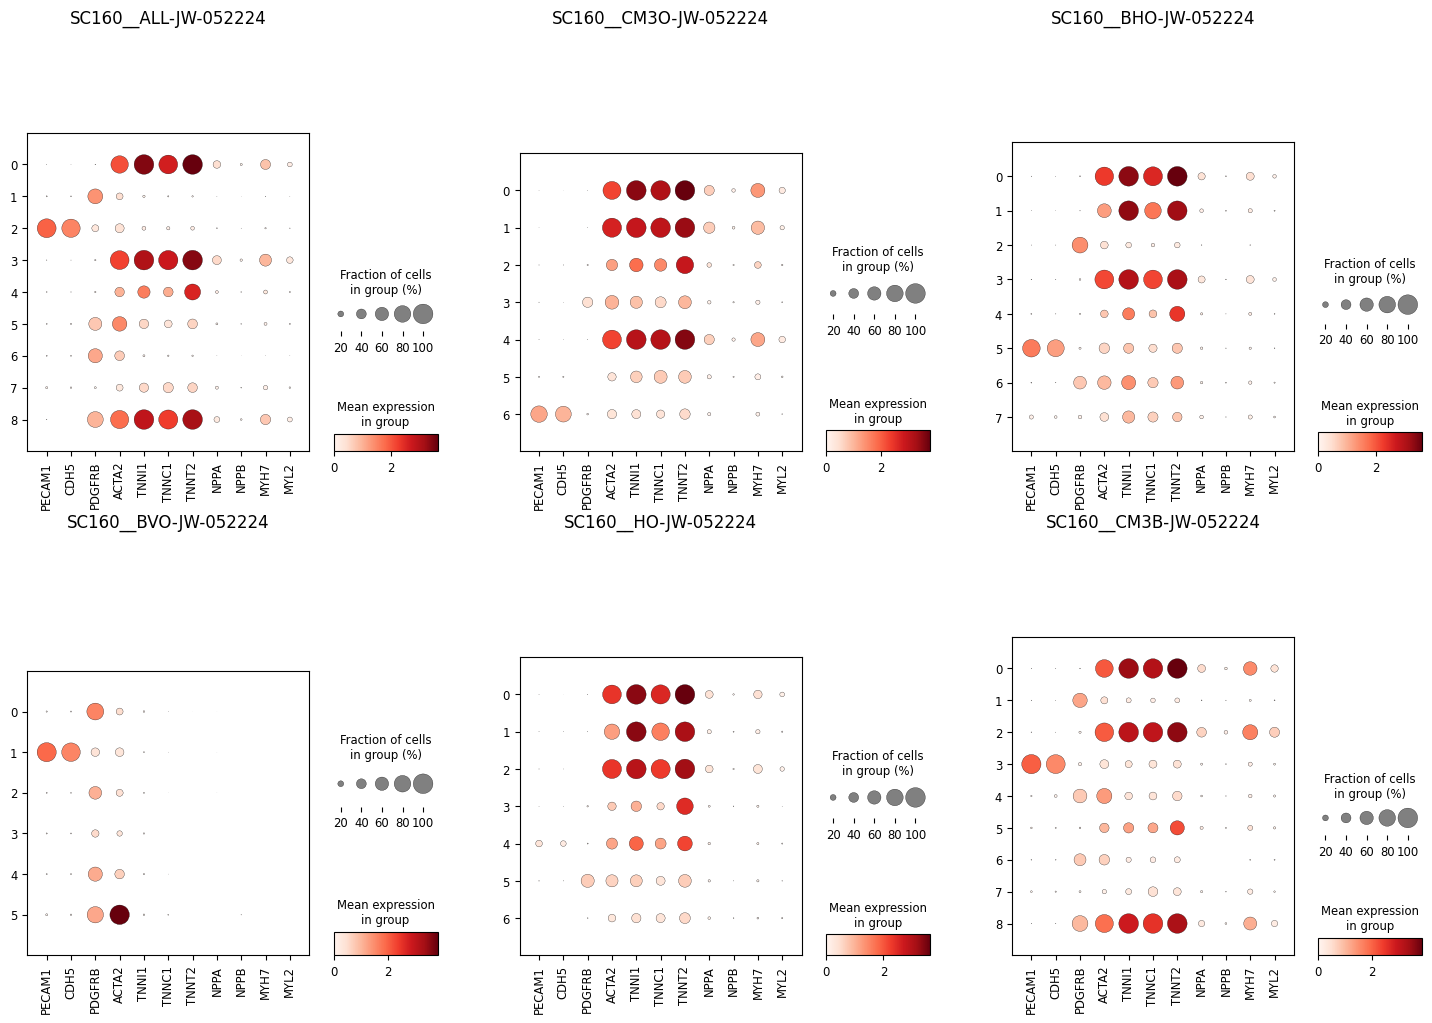

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(18,12), layout="constrained")
axs = axs.flatten()
# axs[-1].remove()

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad.clustered')):
    # try:
    sample_name = d1.split('/')[-1].strip('.h5ad.clustered')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, var_names=marker_genes, groupby='leiden', ax=axs[i], title=sample_name, show=False)
    # except:
    #     continue
    
plt.savefig(f'{OUT_DIR}/gene_marker_umap/dotplots.png')
plt.show()

## 4. label clusters

In [48]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/celltype_label

In [27]:
# Criteria:
#     Blood Vessel Endothelial Cells:    PECAM1+ && CDH5+ && others-
#     Pericytes and Smooth Muscle Cells: PDGFRB+ && ACTA2+ && others-
#     Cardiomyocytes:                    TNNI1+ && TNNC1+ && TNNT2+ && ACTA2+/- && others-

samples = ['BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    'BVO': {
        '0': 'P & SMC', 
        '1': 'BVE',
        '2': 'Others', 
        '3': 'Others', 
        '4': 'Others', 
        '5': 'P & SMC',
    }, 
    'HO': {
        '0': 'CM', 
        '1': 'CM', 
        '2': 'CM', 
        '3': 'Others', 
        '4': 'CM', 
        '5': 'Others', 
        '6': 'Others', 
    },
    'CM3O': {
        '0': 'CM', 
        '1': 'CM', 
        '2': 'CM', 
        '3': 'Others', 
        '4': 'CM', 
        '5': 'Others', 
        '6': 'BVE',
    },
    'BHO': {
        '0': 'CM', 
        '1': 'CM', 
        '2': 'P & SMC', 
        '3': 'CM', 
        '4': 'Others', 
        '5': 'BVE',
        '6': 'Others', 
        '7': 'Others', 
    },
    'CM3B': {
        '0': 'CM', 
        '1': 'P & SMC', 
        '2': 'CM', 
        '3': 'BVE',
        '4': 'P & SMC', 
        '5': 'Others', 
        '6': 'P & SMC', 
        '7': 'Others', 
        '8': 'CM', 
    },
}

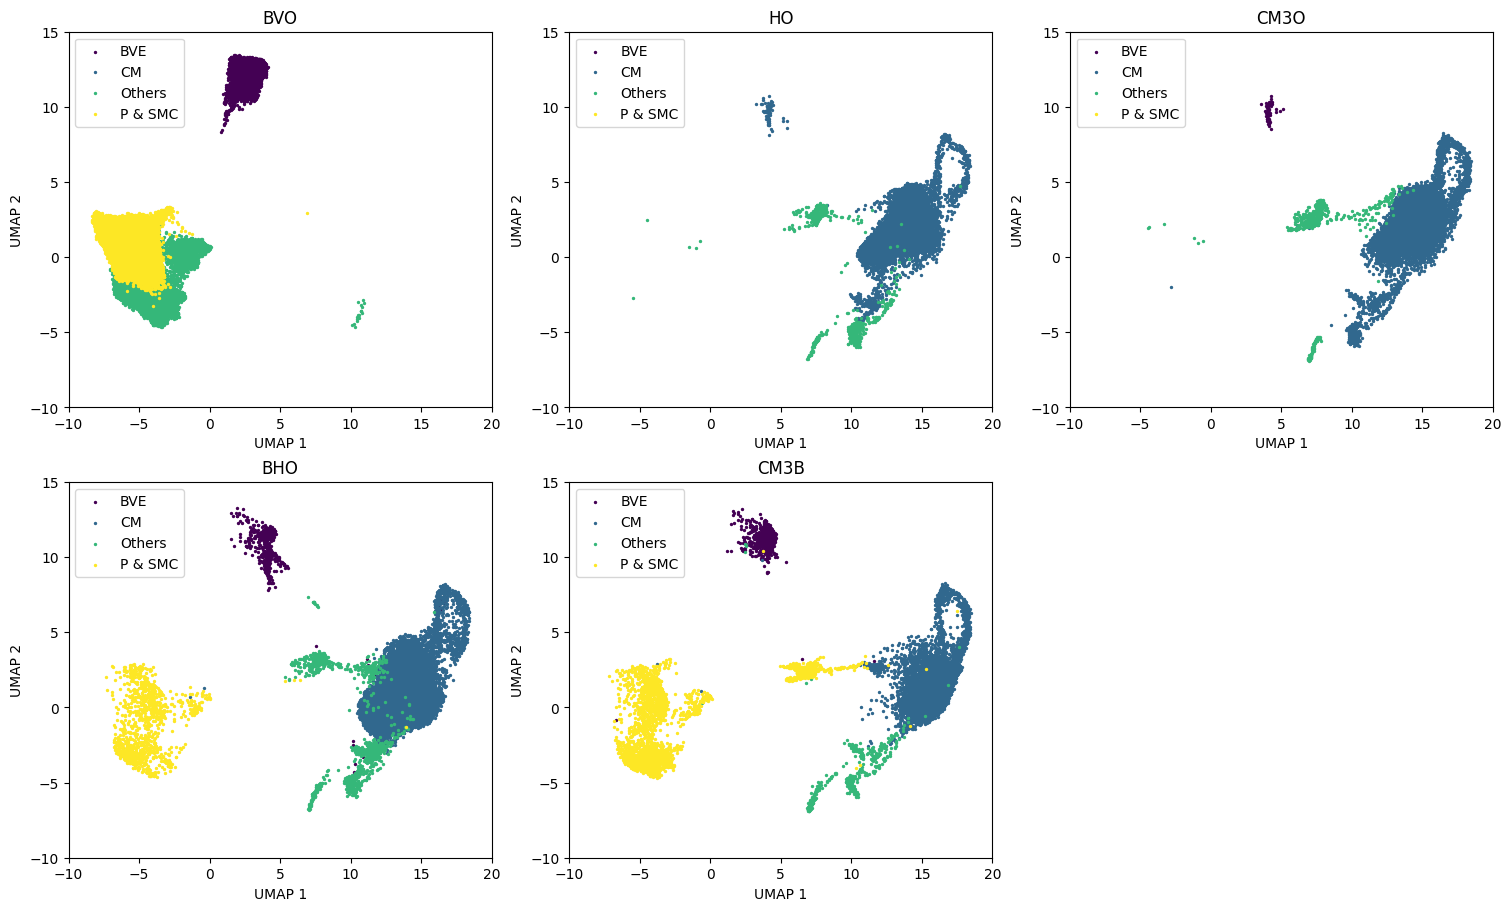

In [184]:
fig, axs = plt.subplots(2, 3, figsize=(15,9), layout="constrained")
axs = axs.flatten()
axs[-1].remove()

cell_types = ['BVE','CM','Others','P & SMC']
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(cell_types)))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{OUT_DIR}/coembed/SC160__{sample}-JW-052224.h5ad.clustered')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict[sample])
    adata.write(f'{OUT_DIR}/celltype_label/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-10, 15])
    
plt.savefig(f'{OUT_DIR}/celltype_label/umap.png')
plt.show()

## 5. Differential Expression

### 5.1 pericytes

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano

In [6]:
adata_BVO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/BVO.h5ad')
adata_HO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{OUT_DIR}/celltype_label/CM3O.h5ad')
adata_BHO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/BHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{OUT_DIR}/celltype_label/CM3B.h5ad')

In [100]:
# adata_dict = {'BVO': adata_BVO, 'HO': adata_HO, 'CM3O': adata_CM3O, 'BHO': adata_BHO, 'CM3B': adata_CM3B}
# cell_types = ['P & SMC', 'BVE', 'CM']
# for k in adata_dict.keys():
#     for ct in cell_types:
#         print(f"{k} - {ct}: {(adata_dict[k].obs['cell_type']==ct).sum()}")

In [129]:
def volcano_plot(adata1, adata2, celltype, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.raw.X[adata1.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT
    data2 = adata2.raw.X[adata2.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
    plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [130]:
# adata1 = adata_CM3O.copy()
# adata2 = adata_CM3B.copy()
# celltype = 'CM'
# title = 'Pericyte and Smooth Muscle Cell (BVO vs BHO)'
# save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BVO.BHO.png'
# save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BVO.BHO.tsv'
# keygenes=None

# if np.any(adata1.var_names != adata2.var_names):
#     raise ValueError('adata var names not unified')

# PSEUDOCOUNT=0.001
# data1 = adata1.raw.X[adata1.obs['cell_type'] == celltype, :].todense().copy()
# data2 = adata2.raw.X[adata2.obs['cell_type'] == celltype, :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
# s = np.squeeze(np.asarray(means)) ** 0.5
# s = s / s.mean() * 5

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= 5]
# idx_inc = [i for i in idx_signi if foldchanges[i] > 2]
# idx_dec = [i for i in idx_signi if foldchanges[i] < -2]

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             label='not significant',
#             color='grey',
#             alpha=0.5,
#             s=s)
# plt.scatter(foldchanges[idx_inc], 
#             transformed_pvalues[idx_inc], 
#             label='up-regulated',
#             color='red',
#             alpha=0.5,
#             s=s[idx_inc])
# plt.scatter(foldchanges[idx_dec], 
#             transformed_pvalues[idx_dec], 
#             label='down-regulated',
#             color='blue',
#             alpha=0.5,
#             s=s[idx_dec])

# if keygenes is not None:
#     for keygene in keygenes:
#         gene_idx = adata1.var_names.tolist().index(keygene)
#         plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)


# plt.xlabel('Log2FC')
# plt.ylabel('-log10 p-value')
# plt.title(title)
# plt.legend()
# # if save is not None:
# #     plt.savefig(save)
# plt.show()

# # if save_tsv is not None:
# #     de_dict = {}
# #     de_dict['gene'] = adata1.var_names.to_list()
# #     de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0)))
# #     de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0)))
# #     de_dict['log2FC'] = foldchanges
# #     de_dict['-log10 p-val'] = transformed_pvalues
# #     pd.DataFrame(de_dict).to_csv(save_tsv, sep='\t')

/tmp/ipykernel_1529068/1428903398.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


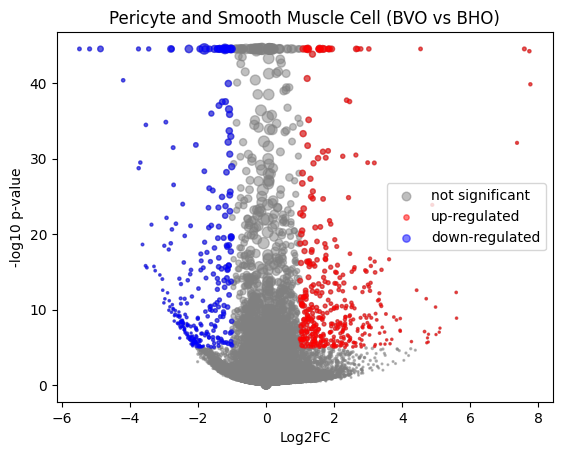

In [131]:
volcano_plot(adata_BVO, 
             adata_BHO, 
             'P & SMC', 
             'Pericyte and Smooth Muscle Cell (BVO vs BHO)', 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BVO.BHO.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BVO.BHO.tsv')

/tmp/ipykernel_1529068/1428903398.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


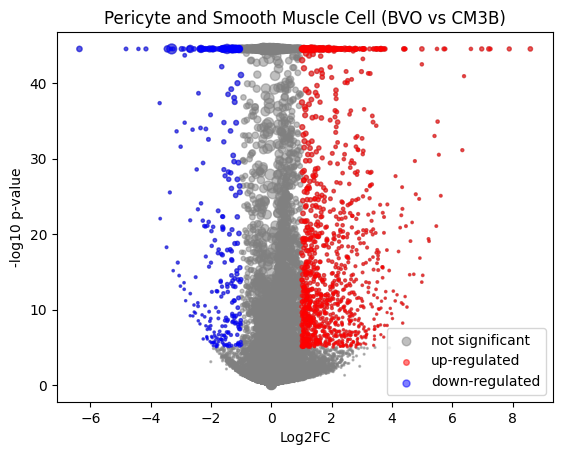

In [132]:
volcano_plot(adata_BVO, 
             adata_CM3B, 'P & SMC', 
             'Pericyte and Smooth Muscle Cell (BVO vs CM3B)', 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BVO.CM3B.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BVO.CM3B.tsv')

/tmp/ipykernel_1529068/1428903398.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


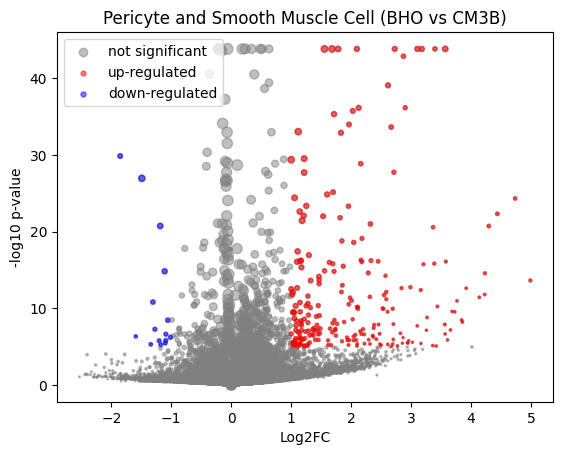

In [133]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'P & SMC', 
             'Pericyte and Smooth Muscle Cell (BHO vs CM3B)', 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BHO.CM3B.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/PASMC.BHO.CM3B.tsv')

### 5.2 Endothelia

/tmp/ipykernel_1529068/1428903398.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


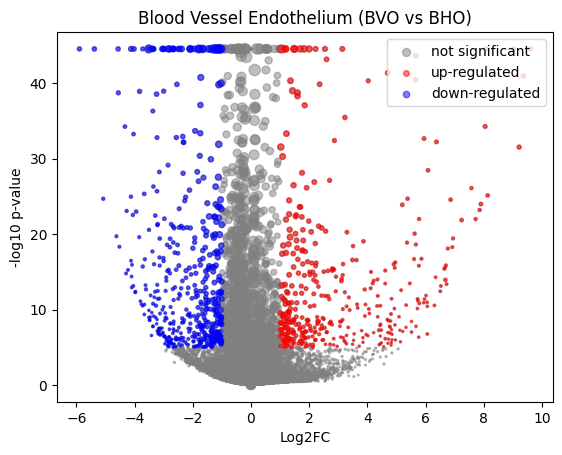

In [134]:
volcano_plot(adata_BVO, 
             adata_BHO, 
             'BVE', 
             'Blood Vessel Endothelium (BVO vs BHO)', 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/BVE.BVO.BHO.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/BVE.BVO.BHO.tsv')

/tmp/ipykernel_1529068/1428903398.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


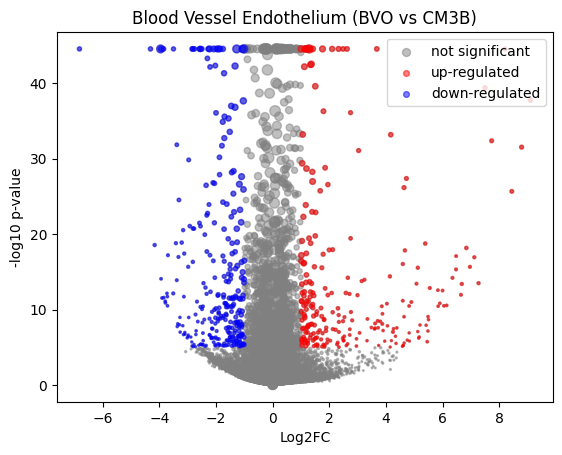

In [135]:
volcano_plot(adata_BVO, 
             adata_CM3B, 
             'BVE', 
             'Blood Vessel Endothelium (BVO vs CM3B)', 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/BVE.BVO.CM3B.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/BVE.BVO.CM3B.tsv')

/tmp/ipykernel_1529068/1428903398.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


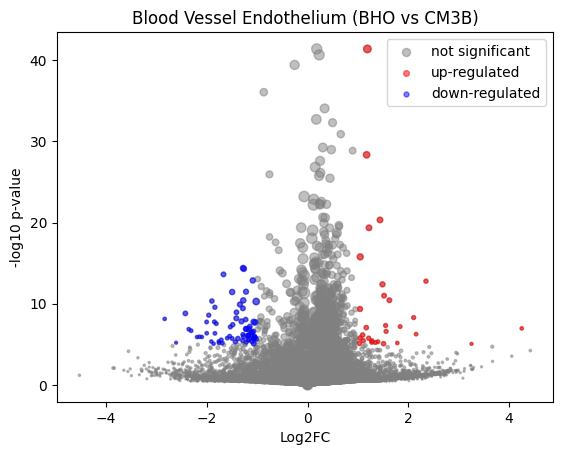

In [136]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'BVE', 
             'Blood Vessel Endothelium (BHO vs CM3B)', 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/BVE.BHO.CM3B.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/BVE.BHO.CM3B.tsv')

### 5.3 Cardiomyocyte

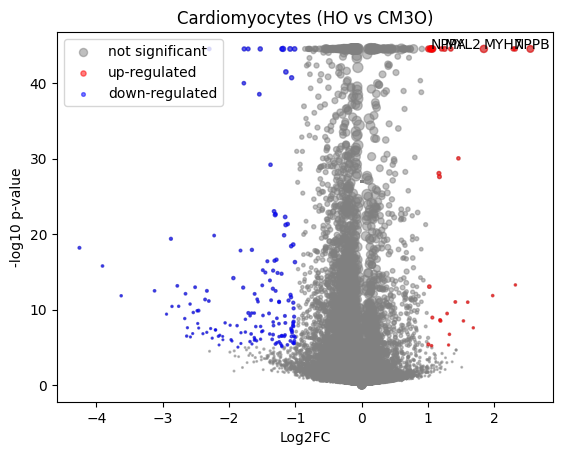

In [137]:
volcano_plot(adata_HO, 
             adata_CM3O, 
             'CM', 
             'Cardiomyocytes (HO vs CM3O)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.HO.CM3O.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.HO.CM3O.tsv')

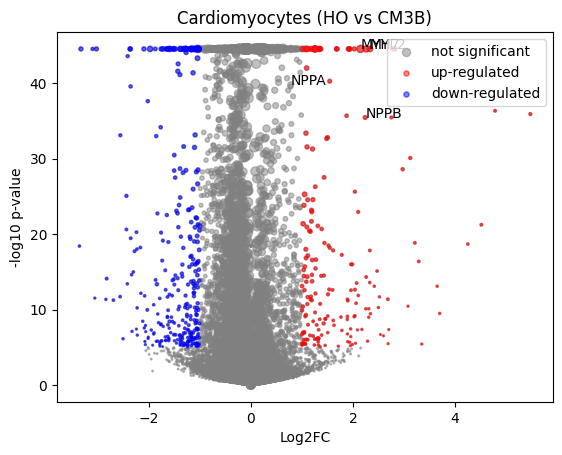

In [138]:
volcano_plot(adata_HO, 
             adata_CM3B, 
             'CM', 
             'Cardiomyocytes (HO vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.HO.CM3B.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.HO.CM3B.tsv')

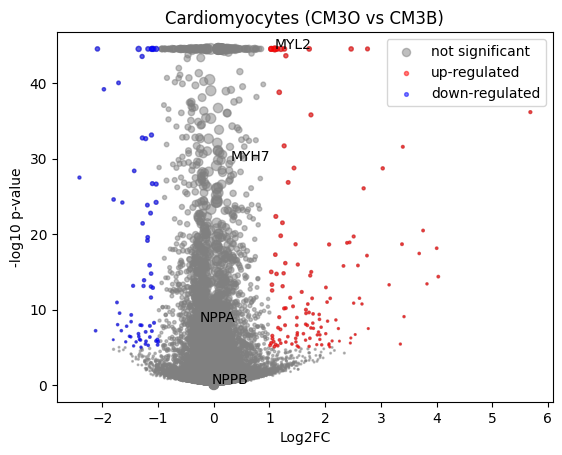

In [139]:
volcano_plot(adata_CM3O, 
             adata_CM3B, 
             'CM', 
             'Cardiomyocytes (CM3O vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.CM3O.CM3B.png', 
             save_tsv='/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.CM3O.CM3B.tsv')

In [59]:
# np.log2(0.1226/0.0753)

In [23]:
# adata_CM3B.raw[:, adata_CM3B.var_names=="NPPB"].X.mean()

In [58]:
# df = pd.read_csv('/home/herbert/PyProjects/cocultured_organ/workspace/CCO03/volcano/CM.HO.CM3B.tsv', sep='\t', index_col=0)
# plt.scatter(df['log2FC'],df['-log10 p-val'])

## 6. try to cluster pericyte

In [22]:
adata_peri = adata_CM3B[adata_CM3B.obs['cell_type'] == 'P & SMC', :].copy()

In [26]:
sc.pp.pca(adata_peri, svd_solver='arpack')
sc.pp.neighbors(adata_peri, n_neighbors=10, n_pcs=50)
sc.tl.leiden(adata_peri, resolution=0.25)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


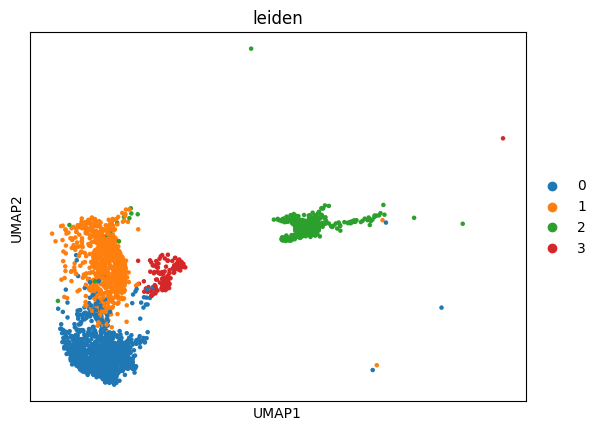

In [27]:
sc.pl.umap(adata_peri, color='leiden')

# 7. look at maturation markers in HO, CM3O, and CM3B

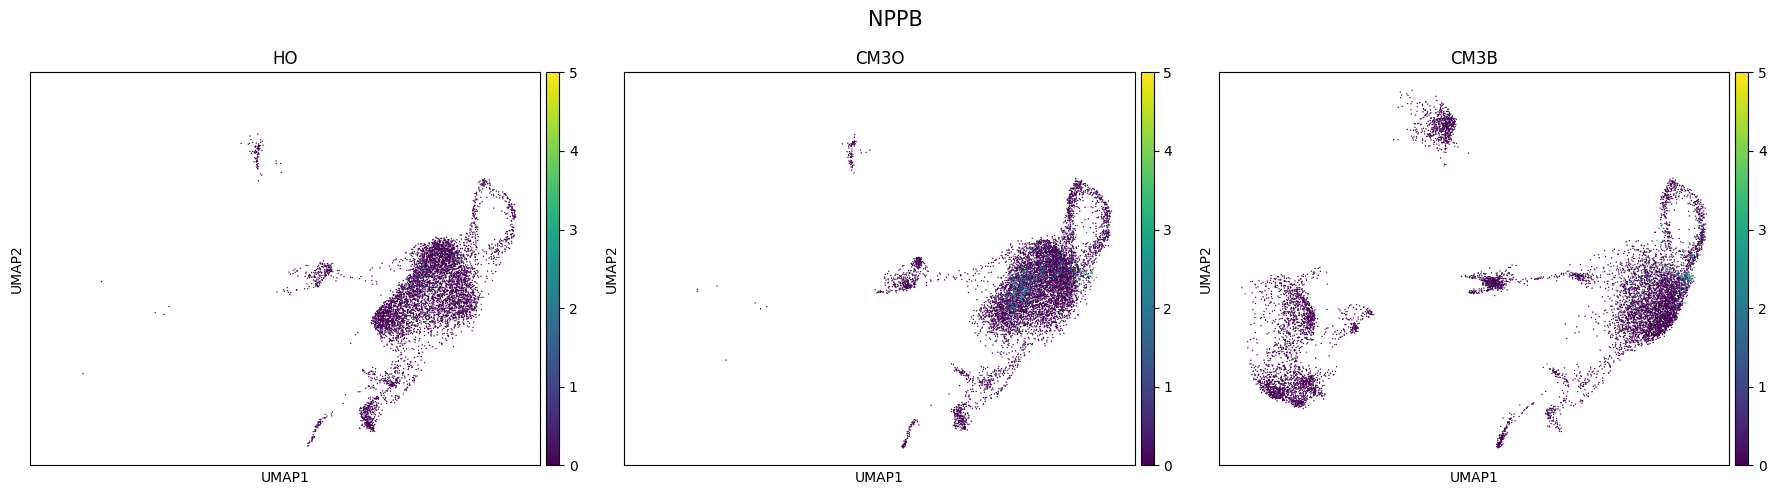

In [158]:
# is NPPB truly not different?
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata_HO, color='NPPB', use_raw=True, show=False, ax=axs[0], title='HO', s=4)
sc.pl.umap(adata_CM3O, color='NPPB', use_raw=True, show=False, ax=axs[1], title='CM3O', s=4)
sc.pl.umap(adata_CM3B, color='NPPB', use_raw=True, show=False, ax=axs[2], title='CM3B', s=4)
fig.suptitle('NPPB', fontsize=15)

# unify axes
clim_min = 0
clim_max = 5
x_min, x_max = float('inf'), float('-inf')
y_min, y_max = float('inf'), float('-inf')
for ax in axs:
    x_min_temp, x_max_temp = ax.get_xlim()
    y_min_temp, y_max_temp = ax.get_ylim()
    x_min = min(x_min, x_min_temp)
    x_max = max(x_max, x_max_temp)
    y_min = min(y_min, y_min_temp)
    y_max = max(y_max, y_max_temp)
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.collections[0].set_clim(clim_min, clim_max)

plt.tight_layout()
plt.show()

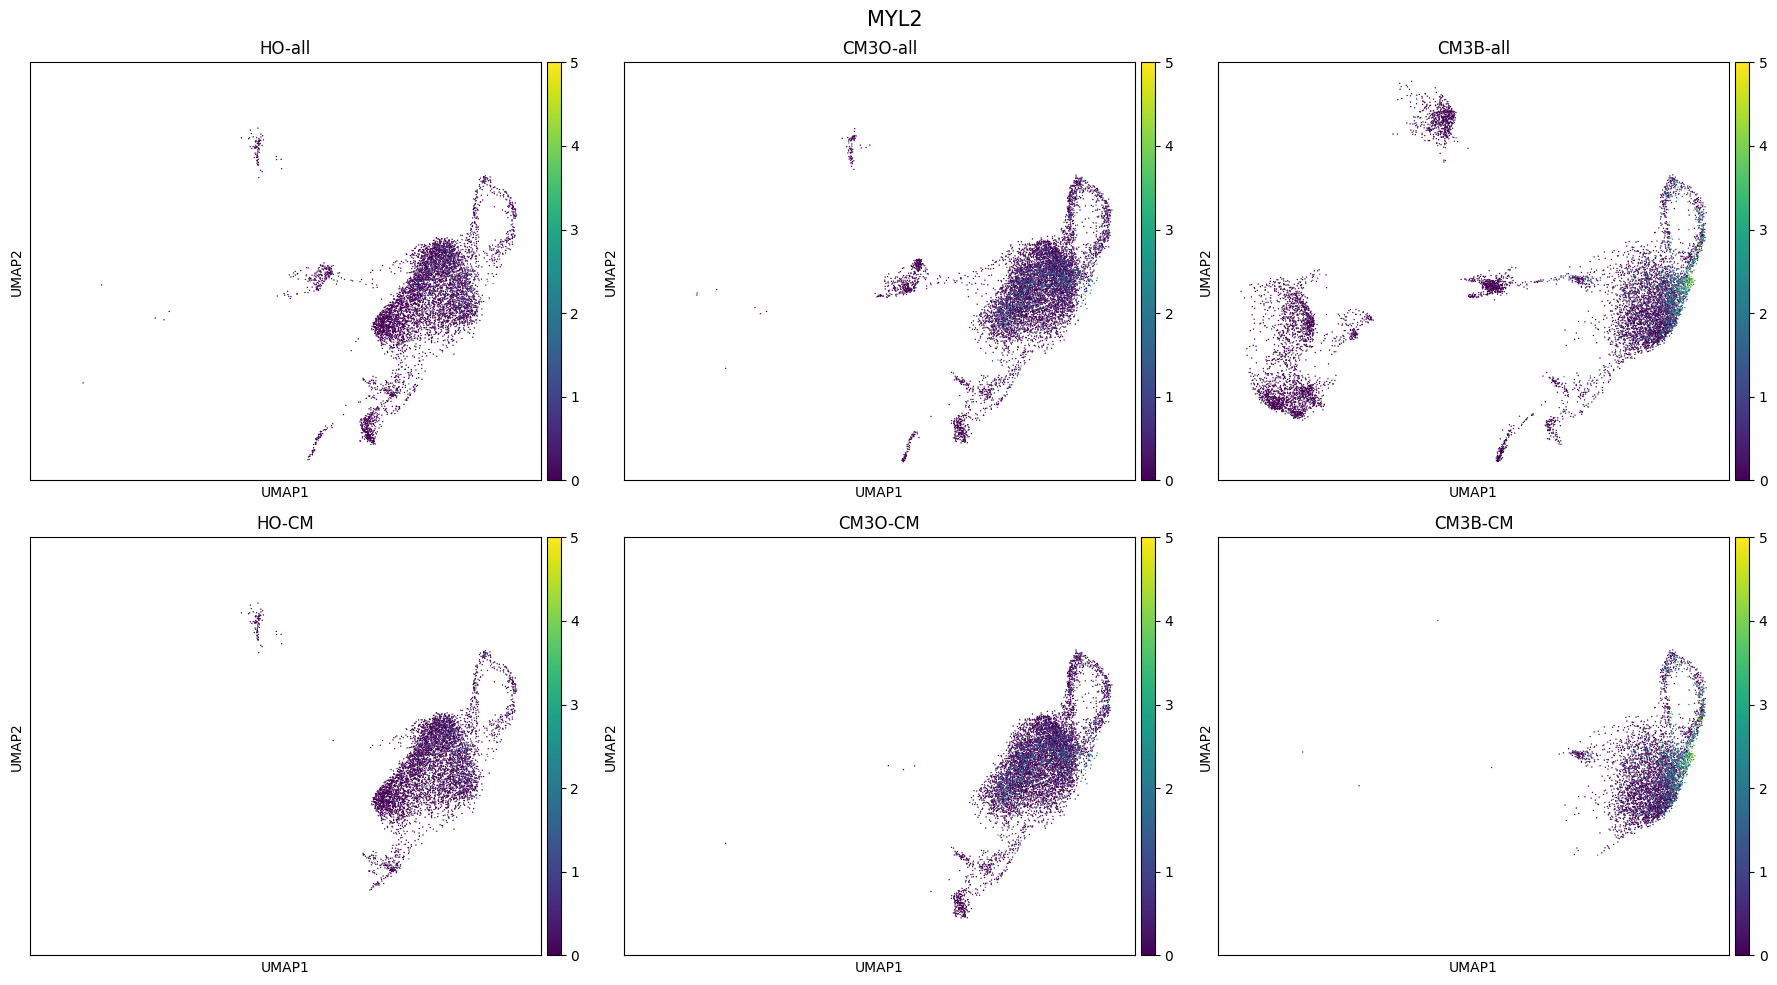

In [157]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()
sc.pl.umap(adata_HO, color='MYL2', use_raw=True, show=False, ax=axs[0], title='HO-all', s=4)
sc.pl.umap(adata_CM3O, color='MYL2', use_raw=True, show=False, ax=axs[1], title='CM3O-all', s=4)
sc.pl.umap(adata_CM3B, color='MYL2', use_raw=True, show=False, ax=axs[2], title='CM3B-all', s=4)
sc.pl.umap(adata_HO[adata_HO.obs['cell_type'] == 'CM'], color='MYL2', use_raw=True, show=False, ax=axs[3], title='HO-CM', s=4)
sc.pl.umap(adata_CM3O[adata_CM3O.obs['cell_type'] == 'CM'], color='MYL2', use_raw=True, show=False, ax=axs[4], title='CM3O-CM', s=4)
sc.pl.umap(adata_CM3B[adata_CM3B.obs['cell_type'] == 'CM'], color='MYL2', use_raw=True, show=False, ax=axs[5], title='CM3B-CM', s=4)
fig.suptitle('MYL2', fontsize=15)

clim_min = 0
clim_max = 5

x_min, x_max = float('inf'), float('-inf')
y_min, y_max = float('inf'), float('-inf')
for ax in axs:
    x_min_temp, x_max_temp = ax.get_xlim()
    y_min_temp, y_max_temp = ax.get_ylim()
    x_min = min(x_min, x_min_temp)
    x_max = max(x_max, x_max_temp)
    y_min = min(y_min, y_min_temp)
    y_max = max(y_max, y_max_temp)
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.collections[0].set_clim(clim_min, clim_max)

plt.tight_layout()
plt.show()

In [156]:
axs[3].collections[0]